In [1]:
import pandas as pd
from pathlib import Path

In [2]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1567, 590)
y shape: (1567, 2)


In [3]:
label_counts = y[0].value_counts()
label_ratio = y[0].value_counts(normalize=True)

print("Label counts:")
print(label_counts)

print("\nLabel ratio:")
print(label_ratio)

Label counts:
0
-1    1463
 1     104
Name: count, dtype: int64

Label ratio:
0
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64


In [4]:
missing_count = X.isna().sum()
missing_ratio = X.isna().mean()

print("전체 결측치 개수:", X.isna().sum().sum())
print("결측치가 있는 feature 개수:", (missing_count > 0).sum())
print("결측치가 없는 feature 개수:", (missing_count == 0).sum())

print("\n결측치 비율이 높은 상위 10개 feature:")
print(missing_ratio.sort_values(ascending=False).head(10))

전체 결측치 개수: 41951
결측치가 있는 feature 개수: 538
결측치가 없는 feature 개수: 52

결측치 비율이 높은 상위 10개 feature:
157    0.911934
292    0.911934
293    0.911934
158    0.911934
492    0.855775
358    0.855775
85     0.855775
220    0.855775
246    0.649649
109    0.649649
dtype: float64


In [5]:
threshold = 0.5

high_missing_features = missing_ratio[missing_ratio >= threshold].index
low_missing_features = missing_ratio[missing_ratio < threshold].index

print("결측치 비율 50% 이상 feature 개수:", len(high_missing_features))
print("결측치 비율 50% 미만 feature 개수:", len(low_missing_features))

print("\n제거 후보 feature:")
print(list(high_missing_features))

결측치 비율 50% 이상 feature 개수: 28
결측치 비율 50% 미만 feature 개수: 562

제거 후보 feature:
[72, 73, 85, 109, 110, 111, 157, 158, 220, 244, 245, 246, 292, 293, 345, 346, 358, 382, 383, 384, 492, 516, 517, 518, 578, 579, 580, 581]


In [6]:
X_reduced = X.drop(columns=high_missing_features)

X_clean = X_reduced.fillna(X_reduced.median())

print("원본 X shape:", X.shape)
print("결측치 많은 feature 제거 후 shape:", X_reduced.shape)
print("최종 X_clean shape:", X_clean.shape)
print("최종 결측치 개수:", X_clean.isna().sum().sum())

원본 X shape: (1567, 590)
결측치 많은 feature 제거 후 shape: (1567, 562)
최종 X_clean shape: (1567, 562)
최종 결측치 개수: 0


In [7]:
feature_variance = X_clean.var()

zero_variance_features = feature_variance[feature_variance == 0].index

print("분산이 0인 feature 개수:", len(zero_variance_features))
print("분산이 0인 feature 목록:")
print(list(zero_variance_features))

분산이 0인 feature 개수: 116
분산이 0인 feature 목록:
[5, 13, 42, 49, 52, 69, 97, 141, 149, 178, 179, 186, 189, 190, 191, 192, 193, 194, 226, 229, 230, 231, 232, 233, 234, 235, 236, 237, 240, 241, 242, 243, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 276, 284, 313, 314, 315, 322, 325, 326, 327, 328, 329, 330, 364, 369, 370, 371, 372, 373, 374, 375, 378, 379, 380, 381, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 414, 422, 449, 450, 451, 458, 461, 462, 463, 464, 465, 466, 481, 498, 501, 502, 503, 504, 505, 506, 507, 508, 509, 512, 513, 514, 515, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538]


In [8]:
X_clean = X_clean.drop(columns=zero_variance_features)

print("상수 feature 제거 후 X_clean shape:", X_clean.shape)

상수 feature 제거 후 X_clean shape: (1567, 446)


In [9]:
pass_mask = y[0] == -1
fail_mask = y[0] == 1

pass_mean = X_clean[pass_mask].mean()
fail_mean = X_clean[fail_mask].mean()
overall_std = X_clean.std()

mean_diff_score = ((fail_mean - pass_mean) / overall_std).abs()
top_mean_diff_features = mean_diff_score.sort_values(ascending=False).head(10)

print("pass 샘플 개수:", pass_mask.sum())
print("fail 샘플 개수:", fail_mask.sum())

print("\npass/fail 평균 차이가 큰 상위 10개 feature:")
print(top_mean_diff_features)

pass 샘플 개수: 1463
fail 샘플 개수: 104

pass/fail 평균 차이가 큰 상위 10개 feature:
59     0.626524
103    0.607336
510    0.528752
348    0.525317
431    0.481663
434    0.447025
430    0.438203
21     0.435065
435    0.434770
28     0.429659
dtype: float64


In [10]:
top_features = top_mean_diff_features.index

comparison_table = pd.DataFrame({
    "pass_mean": pass_mean[top_features],
    "fail_mean": fail_mean[top_features],
    "difference": fail_mean[top_features] - pass_mean[top_features],
    "abs_standardized_difference": top_mean_diff_features
})

print(comparison_table)

       pass_mean    fail_mean  difference  abs_standardized_difference
59      2.555731     8.515123    5.959392                     0.626524
103    -0.009913    -0.008053    0.001860                     0.607336
510    54.430401    74.347949   19.917548                     0.528752
348     0.024263     0.030448    0.006185                     0.525317
431    21.187933    38.707342   17.519410                     0.481663
434    13.716830    28.954783   15.237952                     0.447025
430    17.364169    33.156115   15.791946                     0.438203
21  -5636.360219 -5363.822115  272.538103                     0.435065
435     8.373389    23.306973   14.933584                     0.434770
28     69.597730    68.111542   -1.486188                     0.429659


In [11]:
selected_features = [59, 103, 510]

for feature in selected_features:
    print(f"\nFeature {feature}")
    print("-" * 40)

    print("pass describe:")
    print(X_clean.loc[pass_mask, feature].describe())

    print("\nfail describe:")
    print(X_clean.loc[fail_mask, feature].describe())
    


Feature 59
----------------------------------------
pass describe:
count    1463.000000
mean        2.555731
std         9.291469
min       -28.988200
25%        -1.962750
50%         0.748200
75%         3.890450
max       168.145500
Name: 59, dtype: float64

fail describe:
count    104.000000
mean       8.515123
std       10.802344
min      -12.152700
25%        1.052950
50%        5.522300
75%       15.468650
max       53.681800
Name: 59, dtype: float64

Feature 103
----------------------------------------
pass describe:
count    1463.000000
mean       -0.009913
std         0.002993
min        -0.032900
25%        -0.011900
50%        -0.010200
75%        -0.008400
max         0.020300
Name: 103, dtype: float64

fail describe:
count    104.000000
mean      -0.008053
std        0.003497
min       -0.016000
25%       -0.010600
50%       -0.008200
75%       -0.005700
max        0.006200
Name: 103, dtype: float64

Feature 510
----------------------------------------
pass describe:
coun

In [12]:
X_clean.loc[pass_mask, feature]

0        64.6707
1       141.4365
3       113.5593
4       148.0663
5        68.7351
          ...   
1562     53.1915
1563     29.4372
1564     54.8330
1565     78.4993
1566     75.8621
Name: 510, Length: 1463, dtype: float64

In [15]:
selected_features = [59, 103, 510]

for feature in selected_features:
    print(f"\nFeature {feature}")
    print("-" * 40)

    print("pass describe:")
    print(X_clean.loc[pass_mask, feature].describe())

    print("\nfail describe:")
    print(X_clean.loc[fail_mask, feature].describe())


Feature 59
----------------------------------------
pass describe:
count    1463.000000
mean        2.555731
std         9.291469
min       -28.988200
25%        -1.962750
50%         0.748200
75%         3.890450
max       168.145500
Name: 59, dtype: float64

fail describe:
count    104.000000
mean       8.515123
std       10.802344
min      -12.152700
25%        1.052950
50%        5.522300
75%       15.468650
max       53.681800
Name: 59, dtype: float64

Feature 103
----------------------------------------
pass describe:
count    1463.000000
mean       -0.009913
std         0.002993
min        -0.032900
25%        -0.011900
50%        -0.010200
75%        -0.008400
max         0.020300
Name: 103, dtype: float64

fail describe:
count    104.000000
mean      -0.008053
std        0.003497
min       -0.016000
25%       -0.010600
50%       -0.008200
75%       -0.005700
max        0.006200
Name: 103, dtype: float64

Feature 510
----------------------------------------
pass describe:
coun

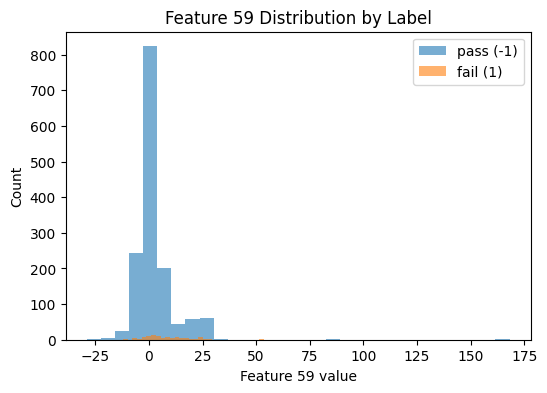

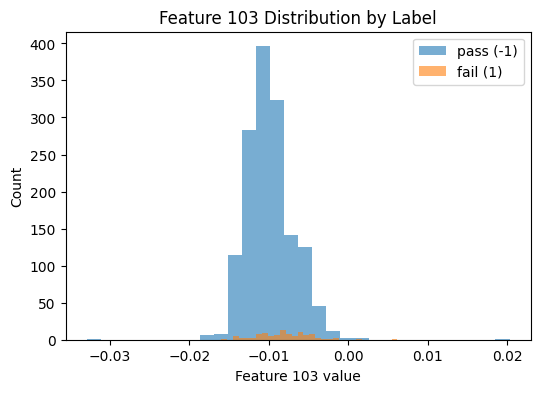

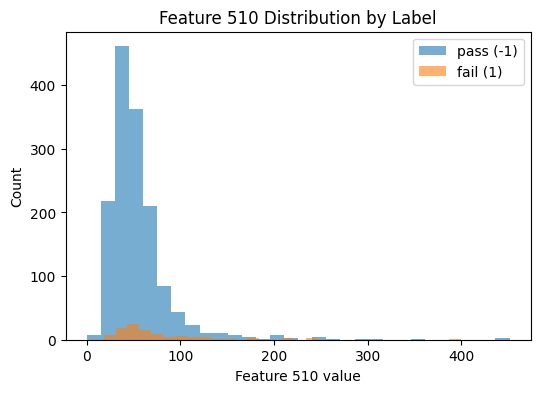

In [17]:
import matplotlib.pyplot as plt

selected_features = [59, 103, 510]

for feature in selected_features:
    plt.figure(figsize=(6, 4))

    plt.hist(
        X_clean.loc[pass_mask, feature],
        bins=30,
        alpha=0.6,
        label="pass (-1)",
    )

    plt.hist(
        X_clean.loc[fail_mask, feature],
        bins=30,
        alpha=0.6,
        label="fail (1)",
    )

    plt.title(f"Feature {feature} Distribution by Label")
    plt.xlabel(f"Feature {feature} value")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

## Initial Data Inspection Summary

- The SECOM feature table has 1,567 samples and 590 anonymized process/sensor features.
- The label table has 1,567 samples and 2 columns: pass/fail label and timestamp.
- The dataset is highly imbalanced:
  - Pass (`-1`): 1,463 samples
  - Fail (`1`): 104 samples
- Missing values are common in the raw feature table.
  - Total missing values: 41,951
  - Features with missing values: 538
  - Features without missing values: 52
- Features with missing ratio greater than or equal to 50% were removed.
  - Removed high-missing features: 28
- Remaining missing values were filled with each feature's median.
- Zero-variance features were removed.
  - Removed zero-variance features: 116
- The final cleaned feature table has 1,567 samples and 446 features.
- The top features with large pass/fail standardized mean differences were:
  - 59, 103, 510, 348, 431, 434, 430, 21, 435, 28
- Feature 59, 103, and 510 showed some distribution shift between pass and fail samples, but none of them alone perfectly separates fail samples.